<a href="https://colab.research.google.com/github/XaVIIIerg/deep-learning-nlp-coursework/blob/main/deep-learning/linear_regression2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

## Linear Regression

Using the rent prices from appartments in Lausanne from PW 02, restricting to the feature living area.

1. Load data and normalise them - as already implemented in the notebook.
2. Reproduce the closed-form solution (of the normal equations) from PW01 (based on pytorch tensors).
3. Implement (full batch) GD for linear regression - by using pytorch tensors. Don't use automatic differentiation, but implement the formulas for the gradient explicitly. Make sure that the your GD descent algorithm works correctly by checking that the solution gradually approaches the correct solution as computed in the first step (within numerical precision). Plot estimated MSE cost vs the number of epochs with matplotlib ("loss curve").
4. Play with different learning rates. Compare the trainings on the basis of the associated loss curves. Describe what you see and interpret what is going on. What is the maximal learning rate that you can use? What happens when choosing a larger learning rate?    
5. Solve the linear regression problem by using pytorch's autograd functionality.     

### 1. Load Data and Normalize

In [ ]:
import pandas as pd
df = pd.read_csv("./lausanne-appart.csv")
N  = df.shape[0]
df.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [ ]:
#normalization
x0 = df.values[:,0]
x = (x0-np.mean(x0))/np.std(x0)
y0 = df.values[:,2]
y = (y0-np.mean(y0))/np.std(y0)

Text(0, 0.5, 'rent_price')

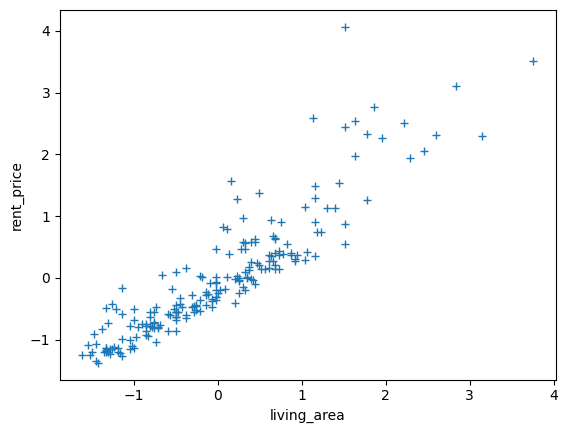

In [ ]:
plt.plot(x, y,"+")
plt.xlabel("living_area")
plt.ylabel("rent_price")

### 2. Linear Model, Normal Equations and Solution

We denote the observed rent by $y_j$ (at time $x_j$) and the model rent by $\hat{y}_j$ we assume

$\qquad \hat{y}_j = \alpha + \beta x_j$

By minimizing the mean squares error

$\qquad C = \frac{1}{2N}\sum_j \left(y_j-\hat{y}_j\right)^2 = C(\alpha,\beta)$

we can fit the straigth line as follows by using the design matrix $X$ and the data vector $Y$, defined by

$\qquad X = \left(\begin{array}{cc} 1 & x_0 \\ 1 & x_1 \\ \vdots & \vdots \\ 1 & x_{N-1}\end{array}\right), \qquad Y = \left(\begin{array}{c} y_0\\ \vdots \\ y_{N-1}\end{array}\right)$

We find

$\qquad \left(\begin{array}{c}\alpha \\ \beta\end{array}\right) = \left(X^T\cdot X\right)^{-1}\cdot X^T\cdot Y$

Hence, here we can easily compute the (linear) model which best fits the training data in the sense of obtaining a minimal mean square error.

#### Solution of Normal Equations in Pytorch

tensor([[-1.5135e-16],
        [ 9.0425e-01]], dtype=torch.float64)


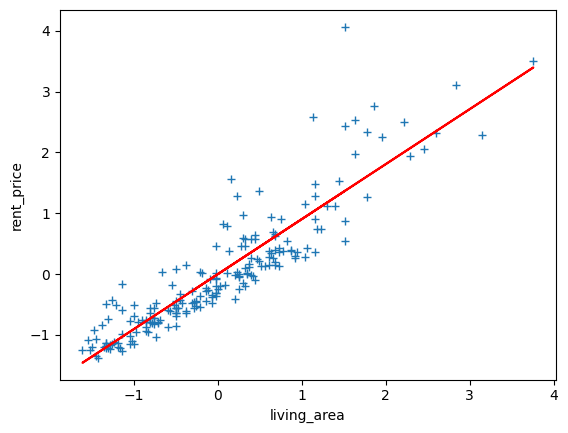

In [ ]:
N = x.size

# YOUR CODE (START)
# compose torch tensors X,Y of shape (N,2) and (N,1) respectively
X = torch.stack([torch.ones(N, dtype=torch.float64), torch.from_numpy(x).double()], dim=1)
Y = torch.from_numpy(y).double().reshape(N, 1)

# solution of normal equations, 'a' a torch tensor of shape (2,1) that contains parameters alpha and beta, which shall be optimized
a_exact = (torch.linalg.inv((X.T) @ X)) @(X.T) @(Y)

# prediction
Yhat = X@a_exact

# YOUR CODE (END)

# plot
plt.plot(X[:,1],Y,"+")
plt.plot(X[:,1],Yhat,'r')
plt.xlabel("living_area")
plt.ylabel("rent_price")
print(a_exact)

The red follows the cloud of points. The line is right ajusted.

Note that with the pytorch function `torch.lstsq` you can obtain the same.

#### Cost

In [ ]:
def cost(X,Y,a):
    # YOUR CODE (START)
    return (1/(2*N))*torch.sum((Y-X@a)**2)
    # YOUR CODE (END)

In [ ]:
min_cost = cost(X,Y,a_exact)
print(min_cost)

tensor(0.0912, dtype=torch.float64)


### 3. Gradient Descent

Specify the gradient of the cost (w.r.t. $\alpha, \beta$) here as maths expression.

In [ ]:
def gradient_cost(X,Y,a):
    # YOUR CODE (START)
    return (1/N)*X.T@(X@a-Y)
    # YOUR CODE (END)

 We have derivated cost(X, Y, a) with respect to a = (alpha, beta), the result is gradC = 1/N * X^T * (aX - Y)

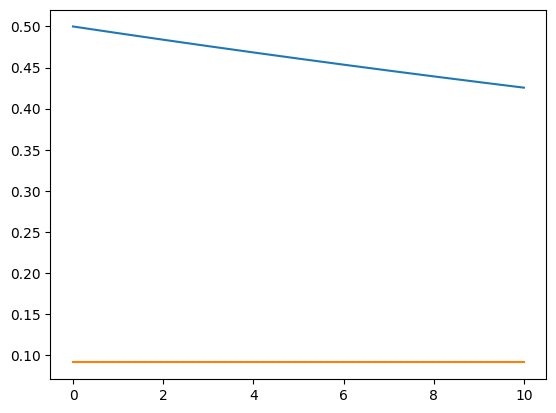

In [ ]:
# adjust if needed
nepochs = 10
lr = 0.01

## initial parameter
a = torch.tensor([0.0,0.0], dtype=torch.float64).reshape(2,1)

# track the costs
costs = []

# YOUR CODE (START)

# loop over the epochs: update parameter values, compute the cost and add it to the costs list
for epoch in range(nepochs):
    costs.append(cost(X,Y,a))
    a = a - lr * gradient_cost(X,Y,a)

costs.append(cost(X,Y,a))

# YOUR CODE (END)

# some output
cost_gd = costs[-1]
plt.plot(range(nepochs+1),costs)
plt.plot(range(nepochs+1),min_cost*torch.ones(nepochs+1))

The learning rate and the number of epoch are not well chosen. The algorithm hasn't converged.

### 4. Different Learning Rates

Play with different learning rates: Explore for what learning rates
- the learning is most efficient
- the learning yet works
- the learning does not work anymore (learning rate too large)

Explain the different scenarios.

    - First case : lr = 10

    The learning rate is too high, we see can the divergence of the algorithm.

Text(0.5, 1.0, 'epoch = 10, lr = 10')

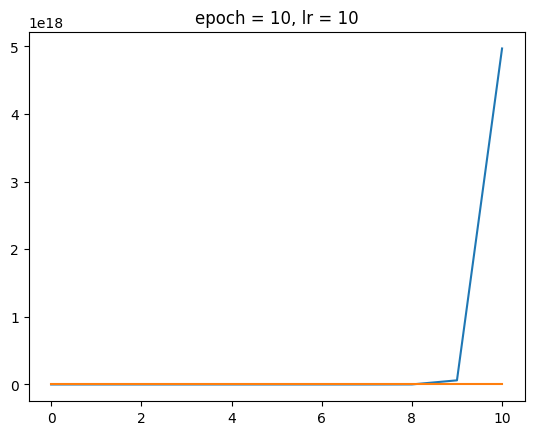

In [ ]:
nepochs = 10
lr = 10

a = torch.tensor([0.0,0.0], dtype=torch.float64).reshape(2,1)
costs = []
for epoch in range(nepochs):
    costs.append(cost(X,Y,a))
    a = a - lr * gradient_cost(X, Y, a)

costs.append(cost(X,Y,a))
cost_gd = costs[-1]
plt.plot(range(nepochs+1),costs)
plt.plot(range(nepochs+1),min_cost*torch.ones(nepochs+1))
plt.title(f"epoch = {nepochs}, lr = {lr}")

    - Second case : lr = 0.1

    Now, the learning rate is too low. The algorithm stops before having a satisfying convergence

Text(0.5, 1.0, 'epoch = 10, lr = 0.1')

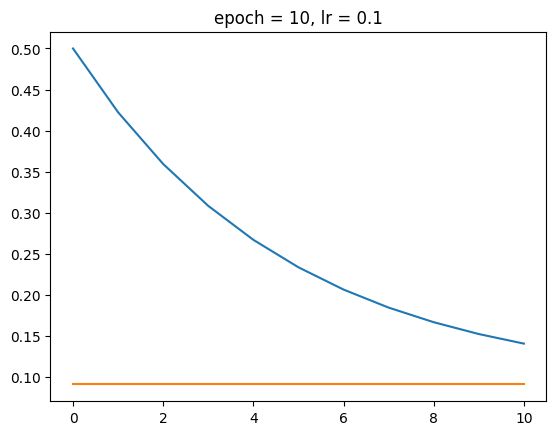

In [ ]:
nepochs = 10
lr = 0.1

a = torch.tensor([0.0,0.0], dtype=torch.float64).reshape(2,1)
costs = []
for epoch in range(nepochs):
    costs.append(cost(X,Y,a))
    a = a - lr * gradient_cost(X, Y, a)

costs.append(cost(X,Y,a))
cost_gd = costs[-1]
plt.plot(range(nepochs+1),costs)
plt.plot(range(nepochs+1),min_cost*torch.ones(nepochs+1))
plt.title(f"epoch = {nepochs}, lr = {lr}")

    - Third case : lr = 0.2

    The learning rate seems to be well chosen because we have an algorithm which converge in a reasonable time.

Text(0.5, 1.0, 'epoch = 10, lr = 0.2')

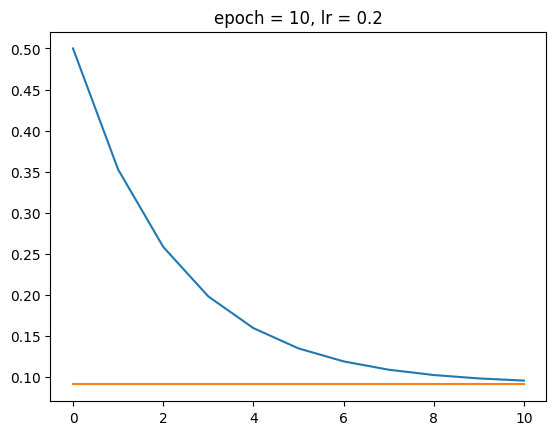

In [ ]:
nepochs = 10
lr = 0.2

a = torch.tensor([0.0,0.0], dtype=torch.float64).reshape(2,1)
costs = []
for epoch in range(nepochs):
    costs.append(cost(X,Y,a))
    a = a - lr * gradient_cost(X, Y, a)

costs.append(cost(X,Y,a))
cost_gd = costs[-1]
plt.plot(range(nepochs+1),costs)
plt.plot(range(nepochs+1),min_cost*torch.ones(nepochs+1))
plt.title(f"epoch = {nepochs}, lr = {lr}")

    We can see that the result is very sensitive to the learning rate. If the learning rate is right for the gradient descend, the blue line converges to the orange line. A good learning rate is high but not too much to not cause divergence.

    The number of epoch is also an important parameter because we want an efficient algorithm without any waste of calculus. A too high nepochs becomes useless when the algorithm has already converged.

    These two parameters must be carefully chosen to optimize the number of calculus and the efficiency of the algorithm.

### 5. Use PyTorch's autograd

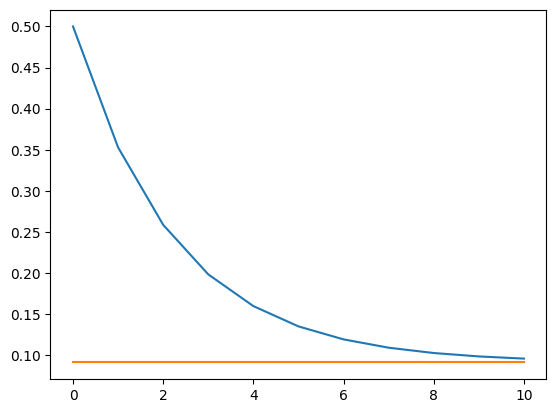

In [ ]:
# adjust if needed
nepochs = 10
lr = 0.2

## initial parameter
a = torch.tensor([0.0,0.0], dtype=torch.float64).reshape(2,1).requires_grad_(True)

# track the costs
costs = []

# YOUR CODE (START)

# loop over the epochs: update parameter values, compute the cost and add it to the costs list
for epoch in range(nepochs):
    #passe forward - on descend le gradient
    loss = cost(X,Y,a)
    costs.append(loss.item()) #permet de stocker les scalaires et pas le graphe
    #passe backward - on arrive au résultat et on remonte en réajustant les points
    loss.backward()
    with torch.no_grad(): #opérations dans cette fonction ne seront pas trackées dans le graphe de calcul
        a -= lr * a.grad #attention sans parenthèse pour le grad
    a.grad.zero_()

costs.append(cost(X,Y,a).item())

# YOUR CODE (END)

# some output

plt.plot(range(nepochs+1),costs)
plt.plot(range(nepochs+1),min_cost*torch.ones(nepochs+1))